In [1]:
%cd ..

/home/eli/AnacondaProjects/wgvp_pc


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys
import warnings

In [3]:
from src import test, train
import src.experiment as experiment

In [4]:
warnings.filterwarnings("ignore")

In [5]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [6]:
metrics

{'loss': np.float32(-64942.49),
 'loss_batch_mean': np.float32(-507.3632),
 'log_w': np.float32(56824.67),
 'log_w_batch_mean': np.float32(443.94275)}

In [7]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

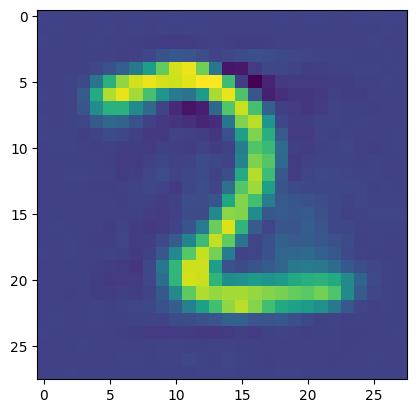

In [8]:
plt.imshow(recons[0].squeeze())

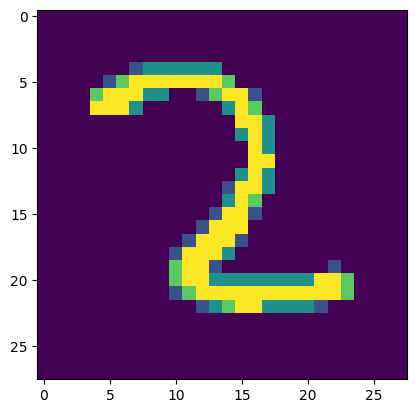

In [9]:
plt.imshow(data[0].squeeze())

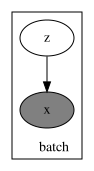

In [10]:
objects['monad'].render_model()

78it [00:09,  7.93it/s]


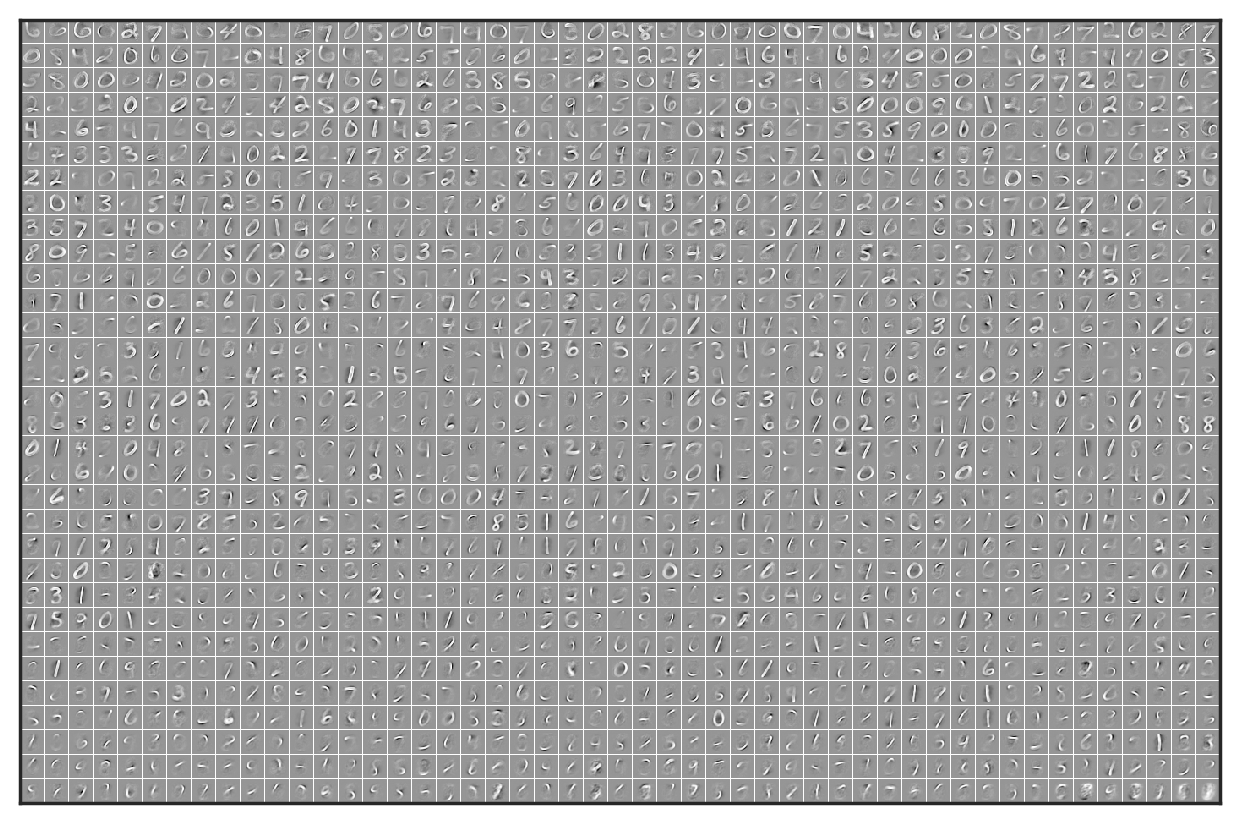

(<Figure size 1600x800 with 1 Axes>, <Axes: >)

In [11]:
u_final = objects["trainer"].proposal_us(objects["datamodule"], objects["monad"], max_steps=100)
u_order = np.argsort(u_final)
experiment.pvae_convergence.show_decoder(objects["datamodule"], objects["monad"].parameters, method="abs-max", order=u_order)

In [12]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [13]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [14]:
portion_zeros(zs)

Array(0.91964245, dtype=float32)

In [15]:
r2(xs, xs_hat)

Array(0.9016864, dtype=float32)

In [16]:
xs.shape

(9984, 1, 28, 28)

In [17]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "data=omniglot", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [18]:
metrics

{'loss': np.float32(-27981.541),
 'loss_batch_mean': np.float32(-218.60579),
 'log_w': np.float32(24483.848),
 'log_w_batch_mean': np.float32(191.28006)}

In [19]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

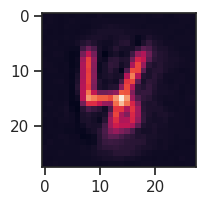

In [20]:
plt.imshow(recons[0].squeeze())

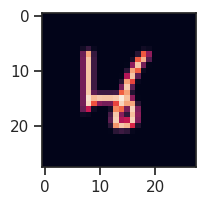

In [21]:
plt.imshow(data[0].squeeze())

102it [00:14,  7.11it/s]


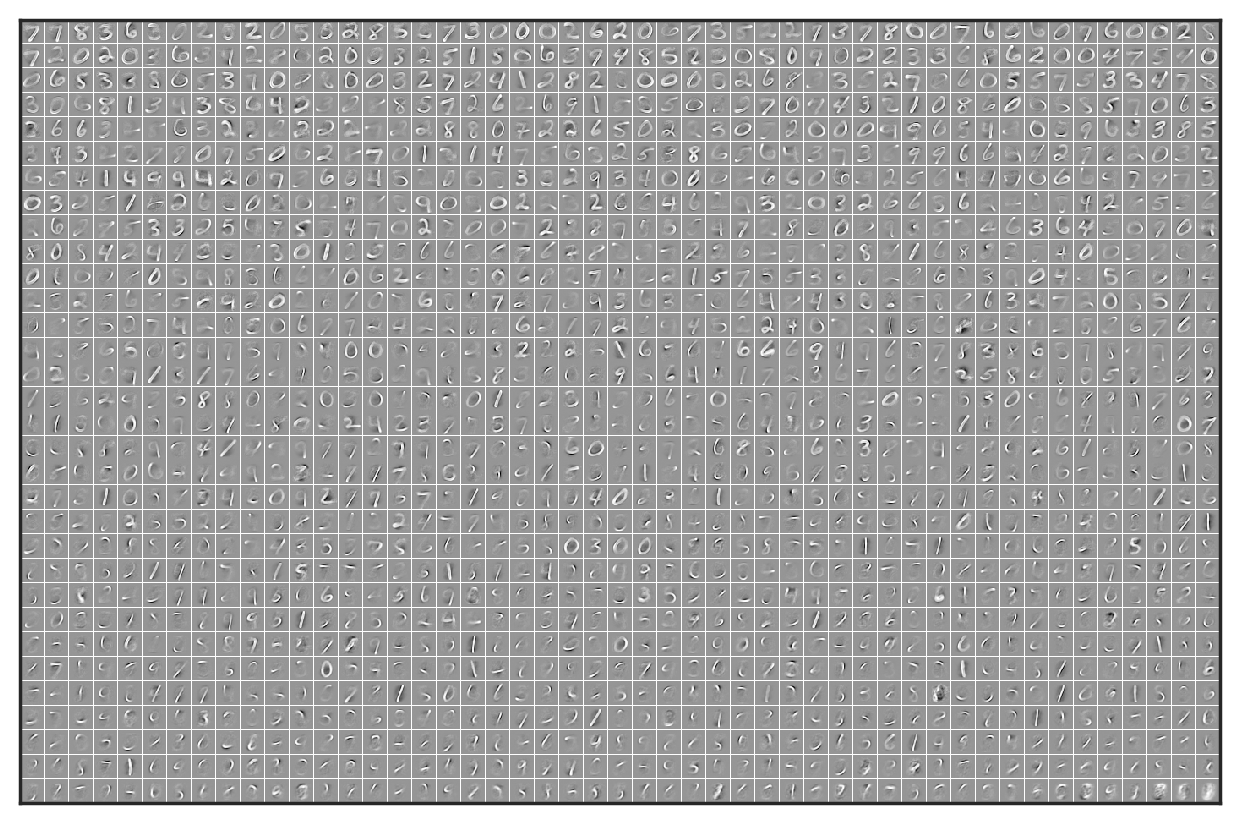

(<Figure size 1600x800 with 1 Axes>, <Axes: >)

In [22]:
u_final = objects["trainer"].proposal_us(objects["datamodule"], objects["monad"], max_steps=100)
u_order = np.argsort(u_final)
experiment.pvae_convergence.show_decoder(objects["datamodule"], objects["monad"].parameters, method="abs-max", order=u_order)

In [23]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [24]:
portion_zeros(zs)

Array(0.9302346, dtype=float32)

In [25]:
r2(xs, xs_hat)

Array(0.62398505, dtype=float32)

In [26]:
xs.shape

(13056, 1, 28, 28)

In [27]:
metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], t_total=100)

15it [07:36, 30.42s/it]


In [28]:
metrics

{'du_norm': Array([168.3044  , 152.72928 , 120.66683 , 108.58345 , 109.91314 ,
        112.35754 , 111.35455 , 109.71601 , 109.84712 , 110.26422 ,
        110.155685, 109.79606 , 109.74858 , 109.797844, 109.73229 ,
        109.64768 , 109.64137 , 109.63359 , 109.62348 , 109.54783 ,
        109.57905 , 109.58225 , 109.550476, 109.525505, 109.51892 ,
        109.528206, 109.5165  , 109.52469 , 109.526764, 109.514496,
        109.55112 , 109.49801 , 109.531   , 109.50509 , 109.51973 ,
        109.51119 , 109.530495, 109.54043 , 109.53688 , 109.531425,
        109.552216, 109.52598 , 109.505615, 109.53085 , 109.538025,
        109.5493  , 109.57008 , 109.505905, 109.56798 , 109.53902 ,
        109.582375, 109.54306 , 109.52861 , 109.54207 , 109.56717 ,
        109.569466, 109.53562 , 109.521805, 109.562004, 109.5673  ,
        109.570465, 109.56857 , 109.54192 , 109.55254 , 109.54537 ,
        109.56583 , 109.550606, 109.56522 , 109.565285, 109.56033 ,
        109.596535, 109.540764, 109.5

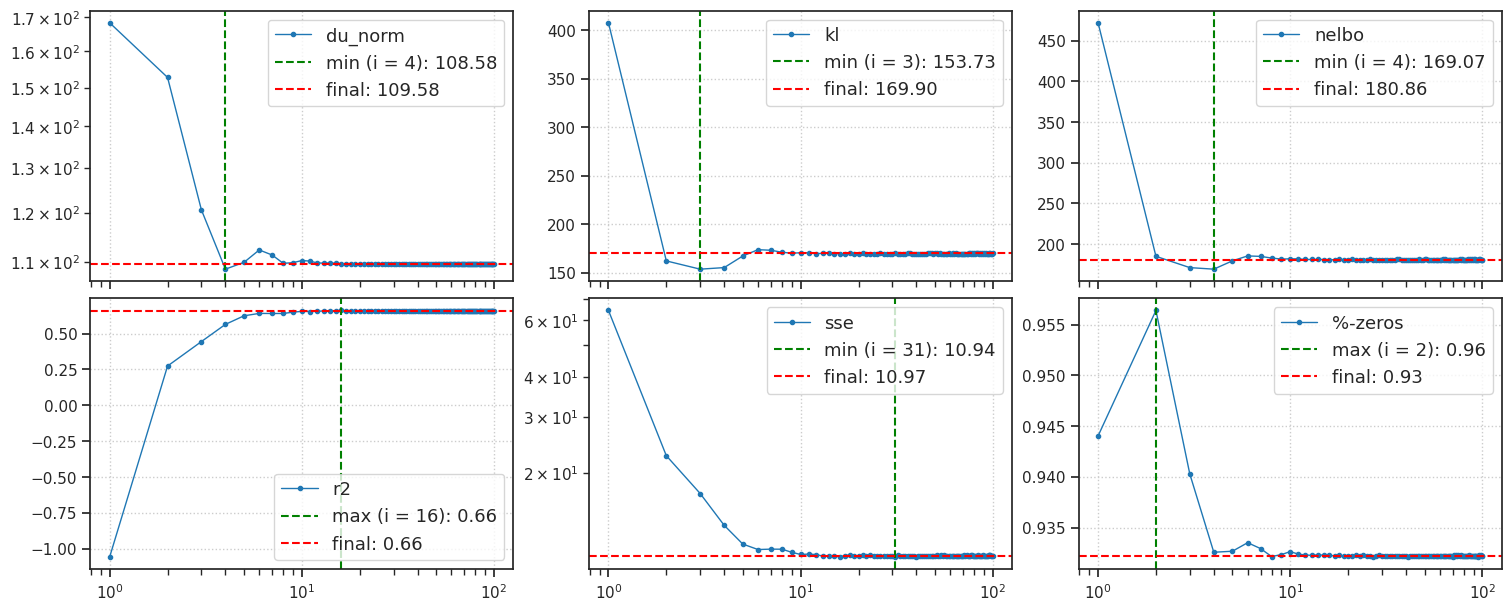

(<Figure size 1500x600 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [29]:
experiment.plot_convergence(metrics)

In [30]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "data=emnist", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [31]:
metrics

{'loss': np.float32(141752.0),
 'loss_batch_mean': np.float32(1107.4375),
 'log_w': np.float32(-124033.0),
 'log_w_batch_mean': np.float32(-969.0078)}

In [32]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

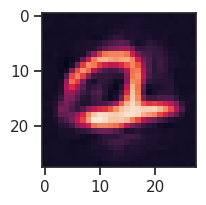

In [33]:
plt.imshow(recons[0].squeeze())

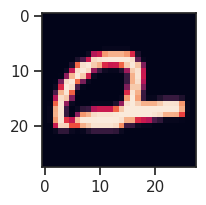

In [34]:
plt.imshow(data[0].squeeze())

146it [00:21,  6.77it/s]


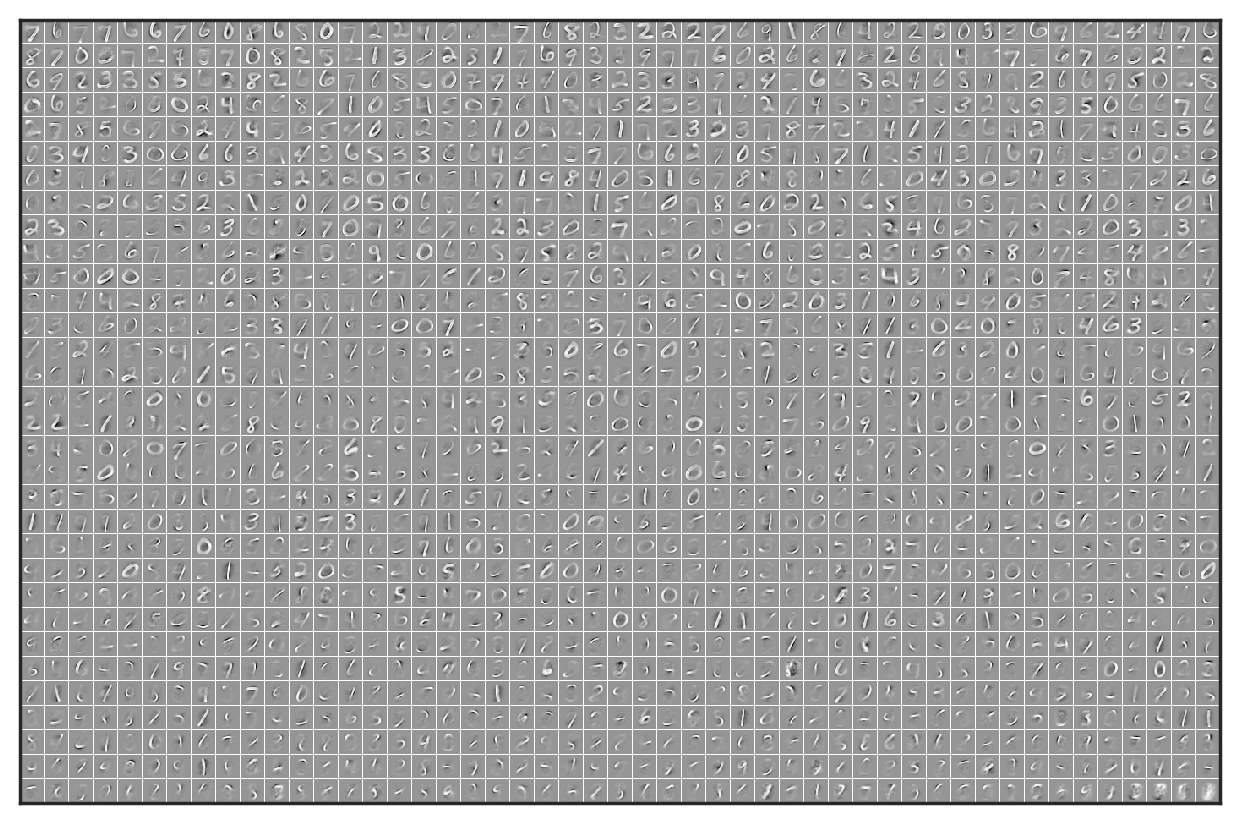

(<Figure size 1600x800 with 1 Axes>, <Axes: >)

In [35]:
u_final = objects["trainer"].proposal_us(objects["datamodule"], objects["monad"], max_steps=100)
u_order = np.argsort(u_final)
experiment.pvae_convergence.show_decoder(objects["datamodule"], objects["monad"].parameters, method="abs-max", order=u_order)

In [36]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [37]:
portion_zeros(zs)

Array(0.91498846, dtype=float32)

In [38]:
r2(xs, xs_hat)

Array(0.5387647, dtype=float32)

In [39]:
xs.shape

(18688, 1, 28, 28)

In [40]:
metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], t_total=100)

88it [47:54, 32.66s/it]


In [41]:
metrics

{'du_norm': Array([165.97823 , 140.80531 , 114.17602 , 106.224304, 108.490776,
        110.26804 , 108.989   , 108.0909  , 108.31247 , 108.512825,
        108.41302 , 108.22499 , 108.144745, 108.178375, 108.16708 ,
        108.099   , 108.07343 , 108.07785 , 108.072586, 108.05666 ,
        108.037735, 108.035034, 108.0344  , 108.0415  , 108.02576 ,
        108.01357 , 108.01649 , 108.019066, 108.016914, 108.01868 ,
        108.01656 , 108.01233 , 108.01128 , 108.01566 , 108.01086 ,
        108.01102 , 108.01804 , 108.02033 , 108.01312 , 108.01642 ,
        108.01768 , 108.02553 , 108.019966, 108.01634 , 108.02179 ,
        108.01708 , 108.02331 , 108.025475, 108.02548 , 108.02563 ,
        108.02402 , 108.02602 , 108.0329  , 108.02759 , 108.027466,
        108.03322 , 108.036255, 108.03531 , 108.037506, 108.03395 ,
        108.03754 , 108.03229 , 108.03612 , 108.03798 , 108.03095 ,
        108.033905, 108.03149 , 108.0376  , 108.029884, 108.03875 ,
        108.03869 , 108.04098 , 108.0

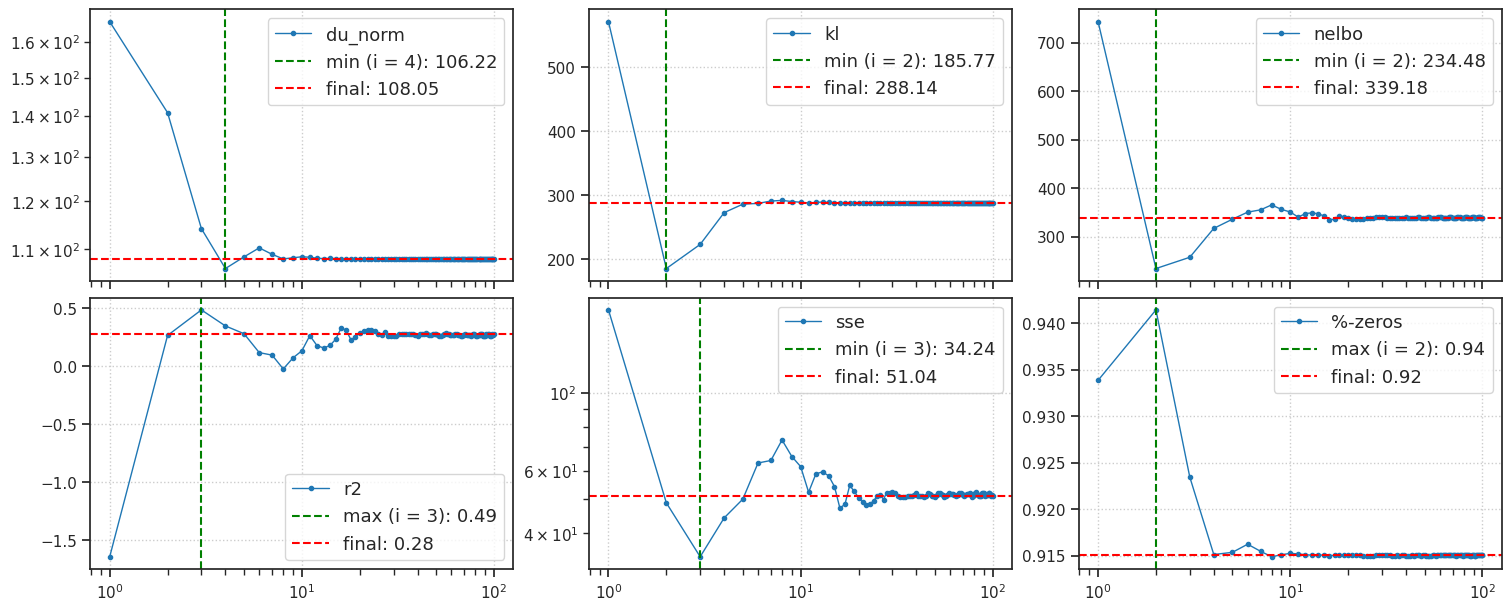

(<Figure size 1500x600 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [42]:
experiment.plot_convergence(metrics)